
# Fake News Detection - Pipeline Complet (Full Dataset)

Ce notebook exécute un pipeline complet de détection de Fake News sur **la totalité de la base de données**.
Parfait pour être exécuté sur Google Colab.

**Objectifs :**
- Fusionner deux datasets complets : Fake and Real News + LIAR (~57 000 articles).
- Tester exhaustivement : 2 Représentations (BoW, TF-IDF) × 3 Feature Selections (Chi2, MI, Fisher) × 8 Top_K × 3 Modèles ML.
- Modèles ML : Logistic Regression, Random Forest, et LinearSVC (optimisé pour les grands datasets).
- Tester 2 Modèles DL : LSTM (Architecture corrigée avec Global Average Pooling et vraie boucle d'entraînement) et DistilBERT.
- Générer des figures approfondies (Courbes d'apprentissage, Matrices de Confusion, ROC).

## 1. Importation des bibliothèques
    

In [16]:

# Importation des bibliothèques de base
import pandas as pd
import numpy as np
import re
import string
import os
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, roc_curve, confusion_matrix, ConfusionMatrixDisplay

# PyTorch et Transformers (Deep Learning)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import DistilBertTokenizer, DistilBertModel

# Création des dossiers de résultats si inexistants
os.makedirs("results/graphes", exist_ok=True)
print("Bibliothèques importées avec succès !")

# Paramétrage GPU pour PyTorch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device PyTorch utilisé : {device}")
    

Bibliothèques importées avec succès !
Device PyTorch utilisé : cpu



## 2. Chargement de toutes les données
Nous fusionnons `Fake and Real News` et `LIAR` sans échantillonnage.
    

Chargement Fake and Real News...
Chargement LIAR Dataset...
Taille totale de la base de données : 57689 articles
  - Fake (1) : 29138 articles
  - Real (0) : 28551 articles

Aperçu des données (5 premières lignes) :


,text,label
0,CARACAS (Reuters) - Venezuelan state elections...,0
1,Says it has offered $12 million in savings thr...,1
2,"The GOP implosion continues, and this time Meg...",1
3,ABOARD AIR FORCE ONE (Reuters) - President Don...,0
4,Famous singer John Legend posted a very offens...,1



Informations sur les colonnes :
<class 'pandas.DataFrame'>
RangeIndex: 57689 entries, 0 to 57688
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    57689 non-null  str  
 1   label   57689 non-null  int64
dtypes: int64(1), str(1)
memory usage: 108.3 MB

Statistiques de longueur des textes par classe :


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,28551.0,293.9,285.7,0.0,39.0,235.0,439.5,5172.0
1,29138.0,344.4,400.2,0.0,39.0,317.0,464.0,8135.0


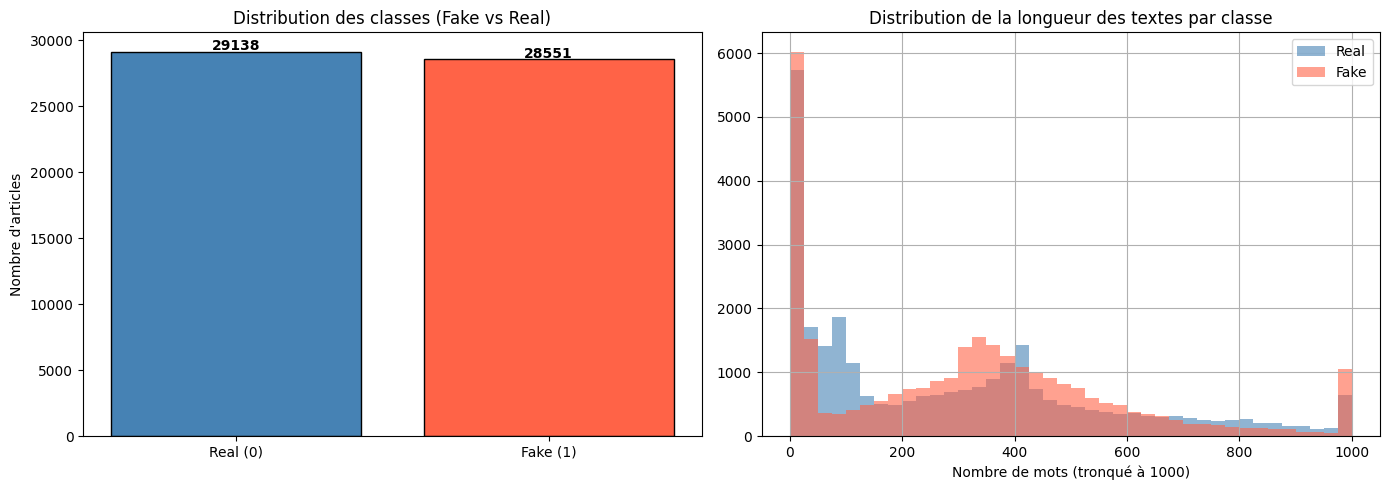

In [17]:

def load_fake_real():
    print("Chargement Fake and Real News...")
    df_fake = pd.read_csv("data/fake_real/Fake.csv")
    df_true = pd.read_csv("data/fake_real/True.csv")
    df_fake['label'] = 1 # Fake
    df_true['label'] = 0 # Real
    df_fr = pd.concat([df_fake, df_true], ignore_index=True)
    df_fr = df_fr[['text', 'label']]
    return df_fr

def load_liar():
    print("Chargement LIAR Dataset...")
    cols = ['id', 'label_text', 'statement', 'subject', 'speaker', 'job', 'state', 'party', 
            'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context']
    
    df_train = pd.read_csv("data/liar/train.tsv", sep='\t', header=None, names=cols)
    df_valid = pd.read_csv("data/liar/valid.tsv", sep='\t', header=None, names=cols)
    df_test = pd.read_csv("data/liar/test.tsv", sep='\t', header=None, names=cols)
    
    df_liar = pd.concat([df_train, df_valid, df_test], ignore_index=True)
    
    fake_labels = ['pants-fire', 'false', 'barely-true']
    df_liar['label'] = df_liar['label_text'].apply(lambda x: 1 if x in fake_labels else 0)
    
    df_liar = df_liar.rename(columns={'statement': 'text'})
    df_liar = df_liar[['text', 'label']]
    return df_liar

df_fr = load_fake_real()
df_liar = load_liar()

# Concaténation totale
df_all = pd.concat([df_fr, df_liar], ignore_index=True)
df_all = df_all.dropna(subset=['text', 'label']).reset_index(drop=True)

# Mélange des données
df_sample = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Taille totale de la base de données : {len(df_sample)} articles")
print(f"  - Fake (1) : {(df_sample['label']==1).sum()} articles")
print(f"  - Real (0) : {(df_sample['label']==0).sum()} articles")

# Aperçu du dataframe
print("\nAperçu des données (5 premières lignes) :")
display(df_sample.head())

# Informations sur les types
print("\nInformations sur les colonnes :")
df_sample.info()

# Longueur des textes
df_sample['text_length'] = df_sample['text'].str.split().str.len()
print("\nStatistiques de longueur des textes par classe :")
display(df_sample.groupby('label')['text_length'].describe().round(1))

# Graphique 1 : Distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
label_counts = df_sample['label'].value_counts()
axes[0].bar(['Real (0)', 'Fake (1)'], label_counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Distribution des classes (Fake vs Real)')
axes[0].set_ylabel("Nombre d'articles")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Graphique 2 : Distribution de la longueur des textes par classe
df_sample[df_sample['label']==0]['text_length'].clip(upper=1000).hist(ax=axes[1], bins=40, alpha=0.6, label='Real', color='steelblue')
df_sample[df_sample['label']==1]['text_length'].clip(upper=1000).hist(ax=axes[1], bins=40, alpha=0.6, label='Fake', color='tomato')
axes[1].set_title('Distribution de la longueur des textes par classe')
axes[1].set_xlabel('Nombre de mots (tronqué à 1000)')
axes[1].legend()
plt.tight_layout()
plt.savefig('results/graphes/data_distribution.png')
plt.show()

    


## 3. Prétraitement du Texte
    

Nettoyage du texte: 100%|██████████| 57689/57689 [00:23<00:00, 2437.95it/s]


Train : 46151 exemples | Test : 11538 exemples

Comparaison Avant / Après nettoyage :


,text,clean_text
0,CARACAS (Reuters) - Venezuelan state elections...,caracas venezuelan state elections may be repe...
1,Says it has offered $12 million in savings thr...,says it has offered 12 million in savings thro...
2,"The GOP implosion continues, and this time Meg...",the gop implosion continues and this time meg ...
3,ABOARD AIR FORCE ONE (Reuters) - President Don...,aboard air force one president donald trump ha...
4,Famous singer John Legend posted a very offens...,famous singer john legend posted a very offens...



Comparaison des longueurs (nombre de mots) :


,text_length,clean_length
count,57689.0,57689.0
mean,319.4,326.4
std,349.2,357.8
min,0.0,0.0
25%,39.0,39.0
50%,287.0,294.0
75%,454.0,464.0
max,8135.0,8374.0


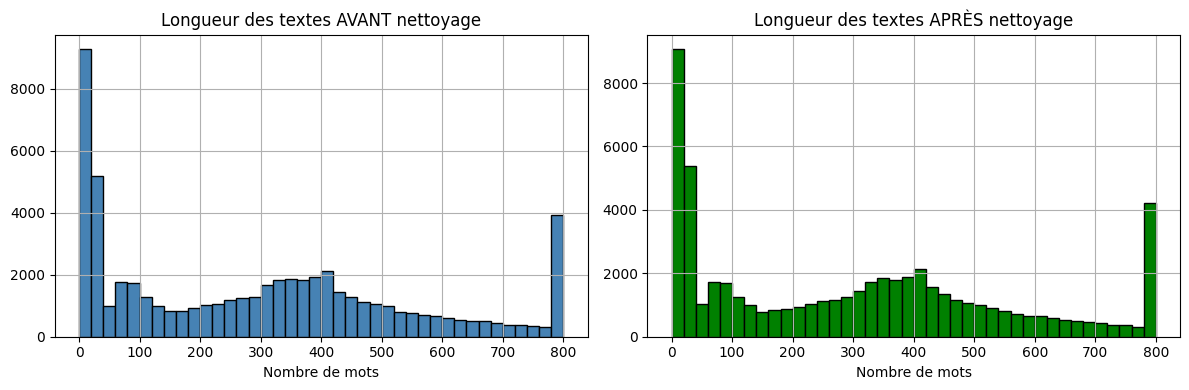

In [18]:

def clean_text(text):
    text = str(text).lower() 
    text = re.sub(r'https?://\S+|www\.\S+', '', text) 
    text = re.sub(r'<.*?>', '', text) 
    text = re.sub(r'\b(reuters)\b', '', text) 
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text) 
    text = re.sub(r'\s+', ' ', text).strip() 
    return text

tqdm.pandas(desc="Nettoyage du texte")
df_sample['clean_text'] = df_sample['text'].progress_apply(clean_text)

# Conversion robuste en NumPy
X = np.array(df_sample['clean_text'].astype(str).tolist(), dtype=object)
y = np.array(df_sample['label'].astype(int).tolist(), dtype=int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train : {len(X_train)} exemples | Test : {len(X_test)} exemples")

# Avant / Après nettoyage
print("\nComparaison Avant / Après nettoyage :")
display(df_sample[['text', 'clean_text']].head(5))

# Longueur après nettoyage
df_sample['clean_length'] = df_sample['clean_text'].str.split().str.len()
print("\nComparaison des longueurs (nombre de mots) :")
display(df_sample[['text_length', 'clean_length']].describe().round(1))

# Graphique : longueur avant et après
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df_sample['text_length'].clip(upper=800).hist(bins=40, color='steelblue', edgecolor='black')
plt.title('Longueur des textes AVANT nettoyage')
plt.xlabel('Nombre de mots')

plt.subplot(1, 2, 2)
df_sample['clean_length'].clip(upper=800).hist(bins=40, color='green', edgecolor='black')
plt.title('Longueur des textes APRÈS nettoyage')
plt.xlabel('Nombre de mots')
plt.tight_layout()
plt.savefig('results/graphes/text_length_distribution.png')
plt.show()

    


## 4. Extraction de Caractéristiques (BoW & TF-IDF)
On limite à 5000 features pour éviter des matrices RAM-intensives sur 57k lignes.
    

In [24]:

print("Création du Bag of Words (BoW)...")
vectorizer_bow = CountVectorizer(max_features=5000, stop_words='english')
X_train_bow = vectorizer_bow.fit_transform(X_train)
X_test_bow = vectorizer_bow.transform(X_test)

print("Création de TF-IDF...")
vectorizer_tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)

print(f"Dimension BoW : {X_train_bow.shape}, TF-IDF : {X_train_tfidf.shape}")
    

Création du Bag of Words (BoW)...
Création de TF-IDF...
Dimension BoW : (46151, 5000), TF-IDF : (46151, 5000)



## 5. Machine Learning Classique - Combinaisons Exhaustives
*Note : SVM a été remplacé par `LinearSVC` qui est un SVM optimisé pour les immenses matrices.*
    

In [25]:
from sklearn.metrics import classification_report

representations = {'BoW': (X_train_bow, X_test_bow), 'TF-IDF': (X_train_tfidf, X_test_tfidf)}
feature_selectors = {'Chi-square': chi2, 'Mutual Information': mutual_info_classif, 'Fisher': f_classif}
top_ks = [20, 40, 100, 200, 400, 600, 1000, 1500]
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, n_jobs=-1, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42),
    'LinearSVC': CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=1000), cv=3)
}

results_list = []
total_combinations = len(representations) * len(feature_selectors) * len(top_ks) * len(models)
counter = 0
best_ml_model_info = {'acc': 0, 'y_pred': None, 'name': ''}

print(f"Debut : {total_combinations} combinaisons sur {len(X_train)} donnees\n")
print("=" * 70)

for rep_name, (X_tr, X_te) in representations.items():
    for fs_name, fs_func in feature_selectors.items():
        for k in top_ks:
            selector = SelectKBest(score_func=fs_func, k=k)
            X_tr_k = selector.fit_transform(X_tr, y_train)
            X_te_k = selector.transform(X_te)

            for mod_name, model in models.items():
                counter += 1
                start_time = time.time()
                model.fit(X_tr_k, y_train)
                train_time = time.time() - start_time

                y_pred = model.predict(X_te_k)
                y_prob = model.predict_proba(X_te_k)[:, 1]

                acc  = accuracy_score(y_test, y_pred)
                prec = precision_score(y_test, y_pred, zero_division=0)
                rec  = recall_score(y_test, y_pred, zero_division=0)
                f1   = f1_score(y_test, y_pred, zero_division=0)
                auc  = roc_auc_score(y_test, y_prob)
                loss = log_loss(y_test, y_prob)

                n_pred_fake = int(y_pred.sum())
                n_pred_real = len(y_pred) - n_pred_fake

                # --- Affichage detaille ---
                print(f"\n[{counter}/{total_combinations}] {rep_name} | {fs_name} | Top-K={k} | {mod_name}")
                print(f"  Temps : {train_time:.2f}s  |  Predictions -> Real(0): {n_pred_real}  Fake(1): {n_pred_fake}")
                print(f"\n  --- Classification Report ---")
                print(classification_report(y_test, y_pred, target_names=['Real (0)', 'Fake (1)'], digits=4))
                print(f"  ROC-AUC: {auc:.4f}  |  Log-Loss: {loss:.4f}")
                print("-" * 70)

                if acc > best_ml_model_info['acc']:
                    best_ml_model_info = {
                        'acc': acc, 'y_pred': y_pred,
                        'name': f"{mod_name} ({rep_name}, {fs_name} Top {k})"
                    }

                results_list.append({
                    'Representation': rep_name, 'Feature_Selection': fs_name,
                    'Top_K': k, 'Model': mod_name,
                    'Accuracy': acc, 'Precision': prec, 'Recall': rec,
                    'F1_score': f1, 'ROC_AUC': auc, 'Log_Loss': loss,
                    'Training_Time': train_time
                })

print(f"\n{'='*70}")
print(f"Toutes les combinaisons ML terminees !")
print(f"Meilleur modele : {best_ml_model_info['name']}  Accuracy={best_ml_model_info['acc']:.4f}")


Debut : 144 combinaisons sur 46151 donnees


[1/144] BoW | Chi-square | Top-K=20 | Logistic Regression
  Temps : 0.33s  |  Predictions -> Real(0): 7172  Fake(1): 4366

  --- Classification Report ---
              precision    recall  f1-score   support

    Real (0)     0.7369    0.9256    0.8205      5710
    Fake (1)     0.9027    0.6762    0.7732      5828

    accuracy                         0.7996     11538
   macro avg     0.8198    0.8009    0.7969     11538
weighted avg     0.8206    0.7996    0.7966     11538

  ROC-AUC: 0.9040  |  Log-Loss: 0.3764
----------------------------------------------------------------------

[2/144] BoW | Chi-square | Top-K=20 | Random Forest
  Temps : 2.58s  |  Predictions -> Real(0): 7093  Fake(1): 4445

  --- Classification Report ---
              precision    recall  f1-score   support

    Real (0)     0.7450    0.9254    0.8254      5710
    Fake (1)     0.9042    0.6896    0.7824      5828

    accuracy                         0.8063     1

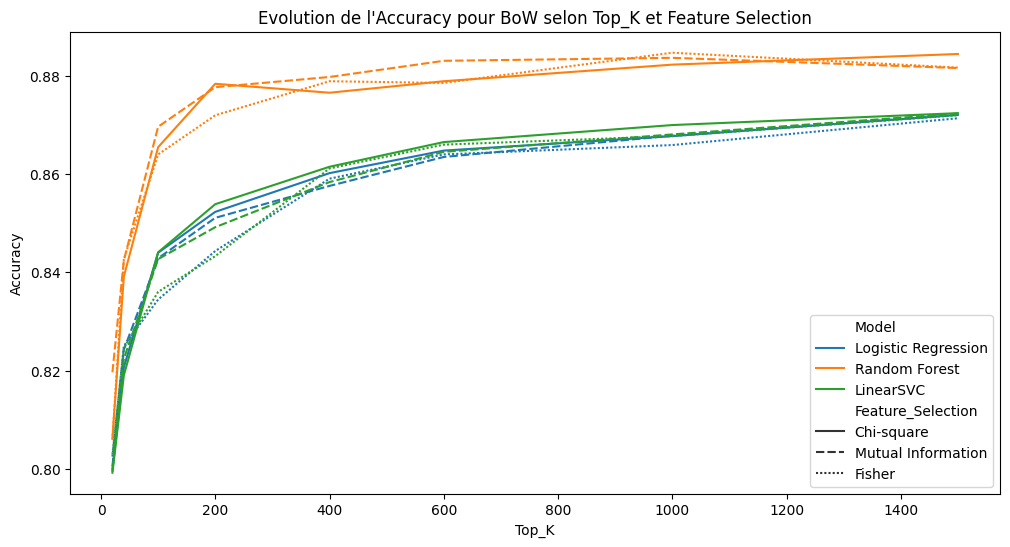

In [26]:
# Graphes : Evolution de l'accuracy en fonction du Top_K pour le meilleur couple Rep/FS
try:
    ml_results = df_results[df_results['Top_K'] != 'All']
    ml_results['Top_K'] = ml_results['Top_K'].astype(int)
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=ml_results[ml_results['Representation']=='BoW'], x='Top_K', y='Accuracy', hue='Model', style='Feature_Selection')
    plt.title("Evolution de l'Accuracy pour BoW selon Top_K et Feature Selection")
    plt.savefig("results/graphes/accuracy_bow_topk.png")
    plt.show()
except Exception as e:
    print("Erreur de plot : ", e)

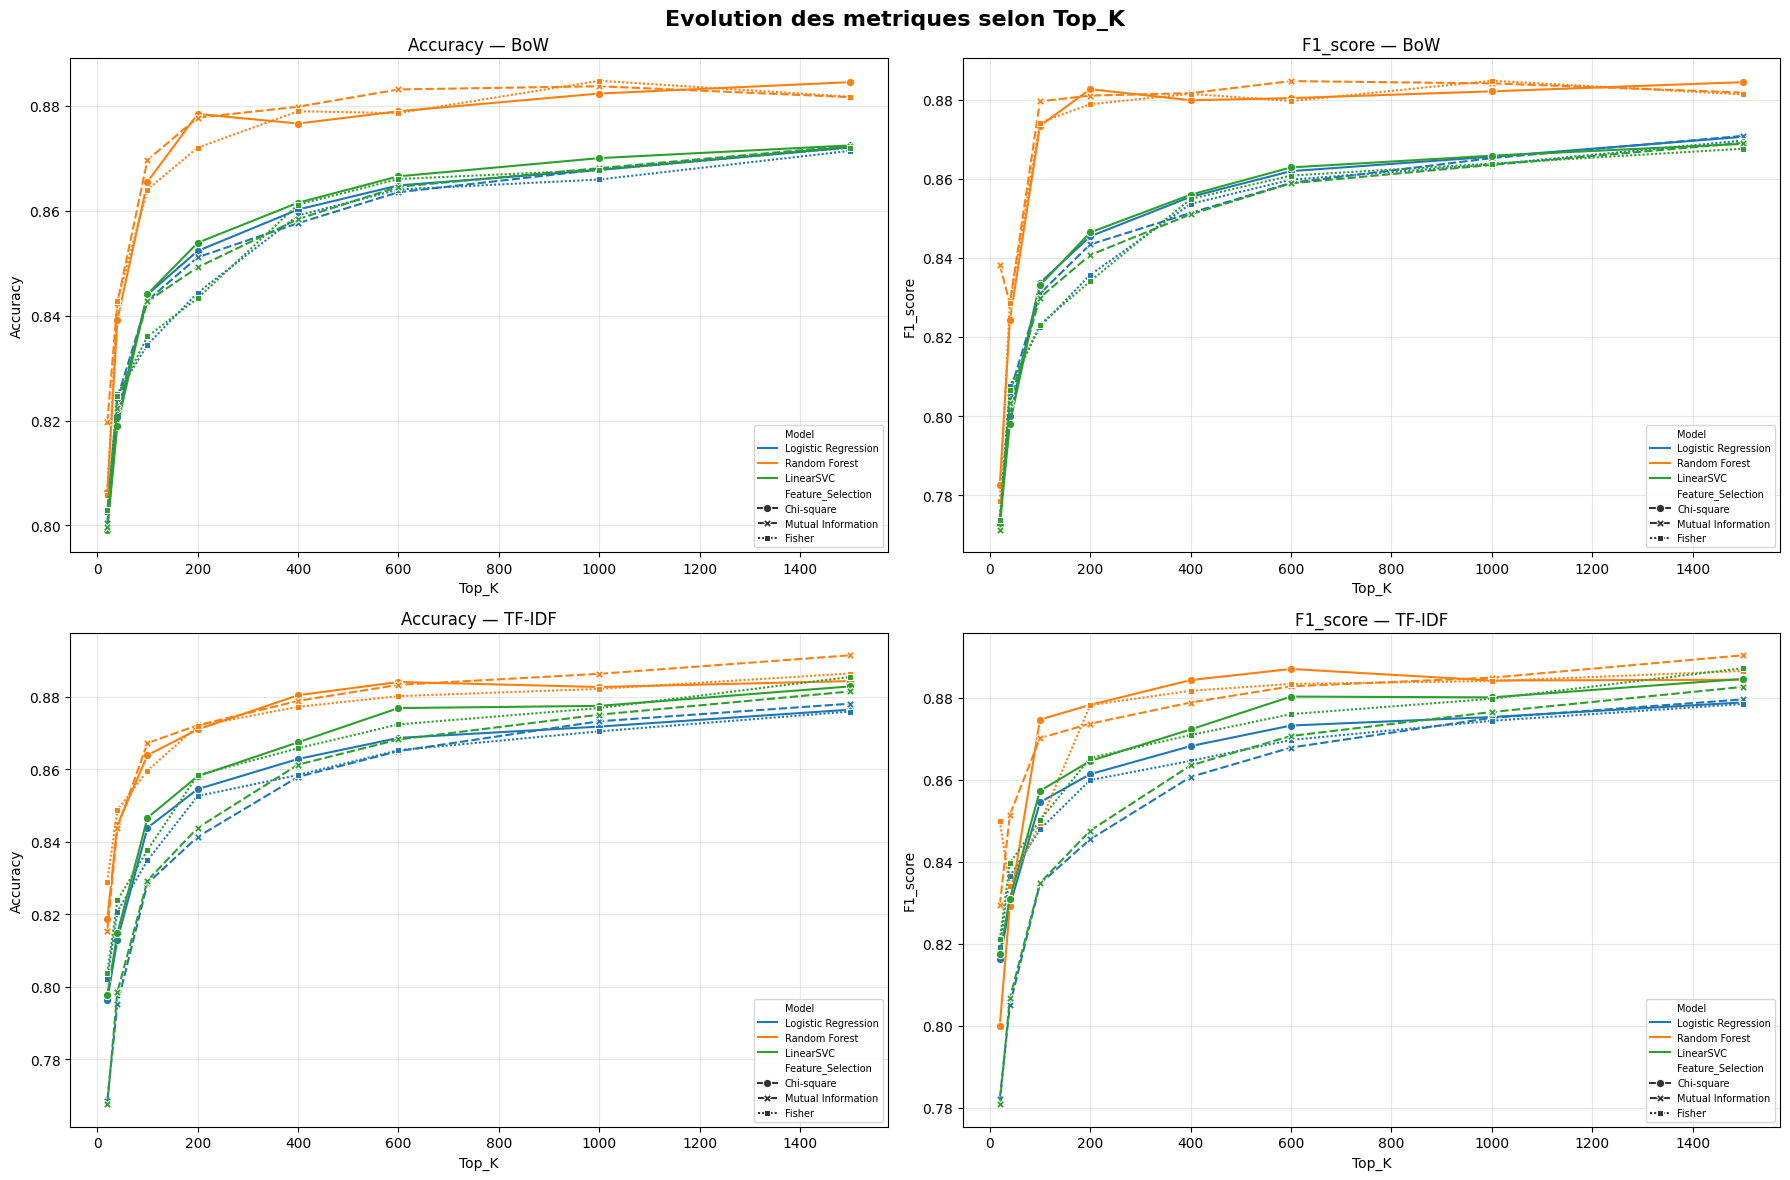

Graphe 1 sauvegarde : metrics_topk_grid.png


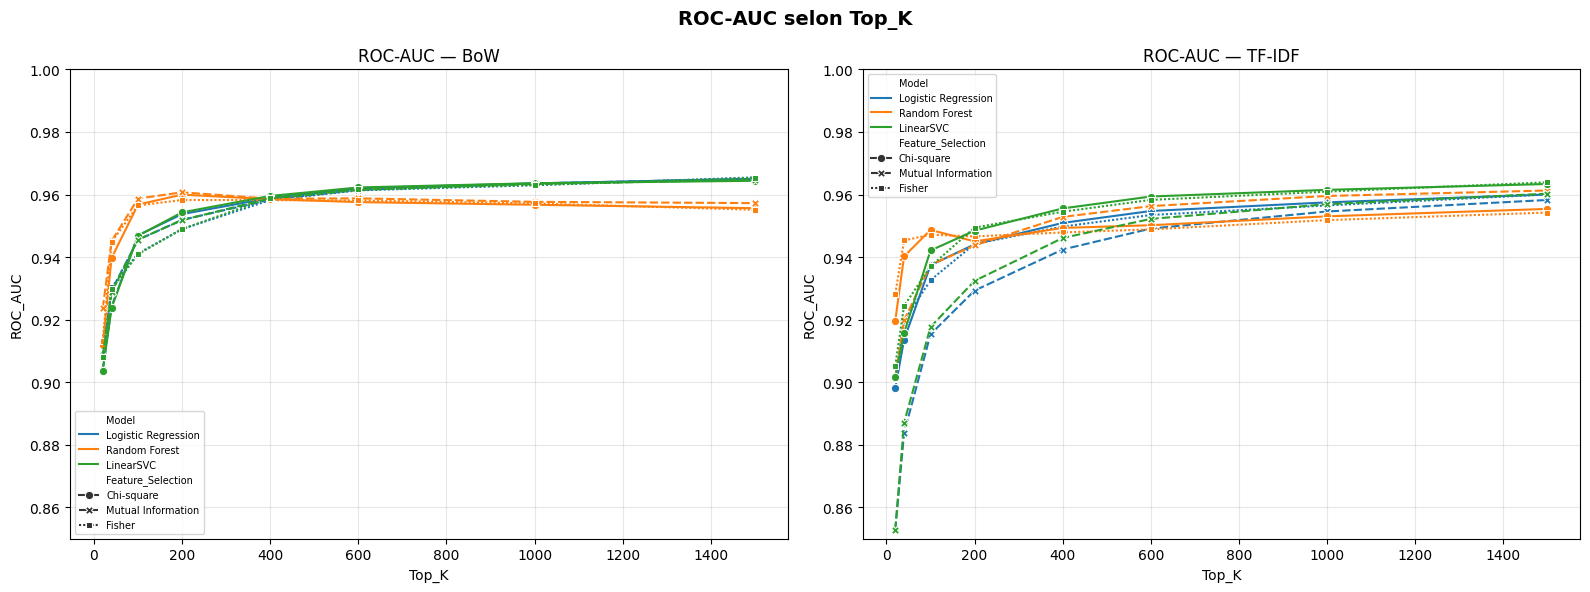

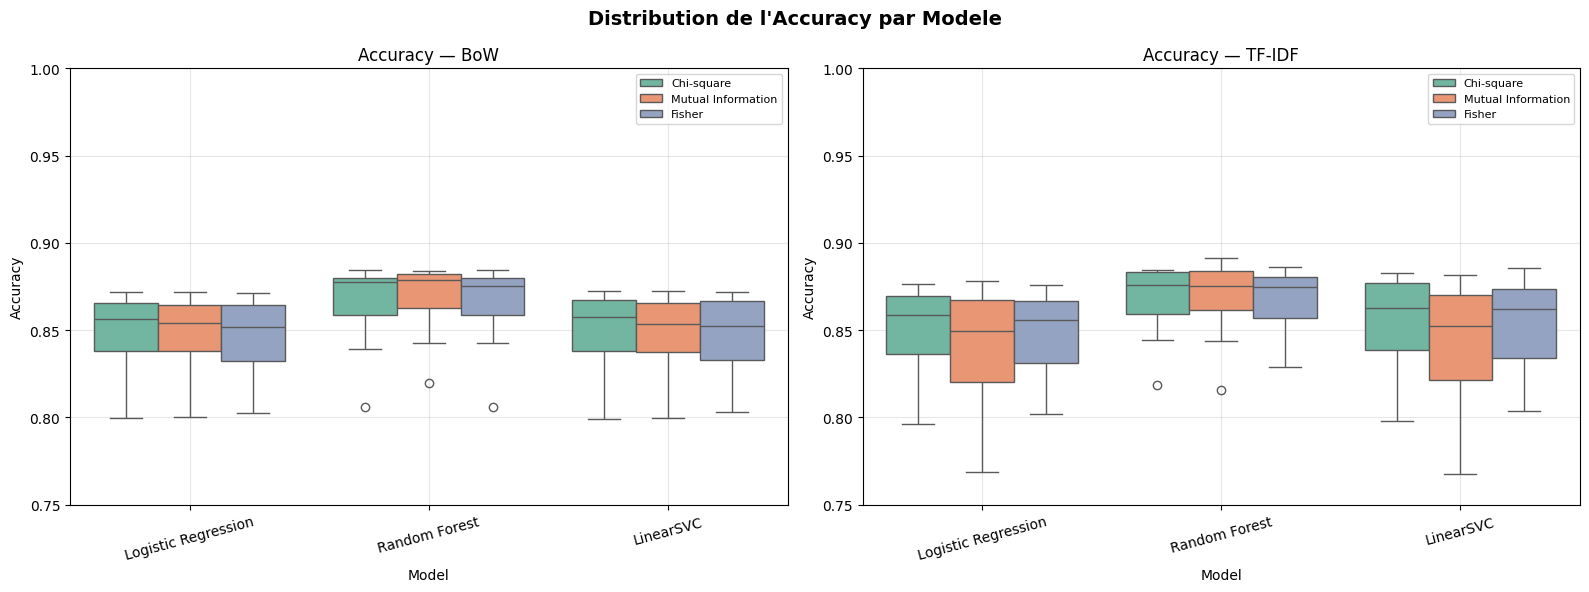

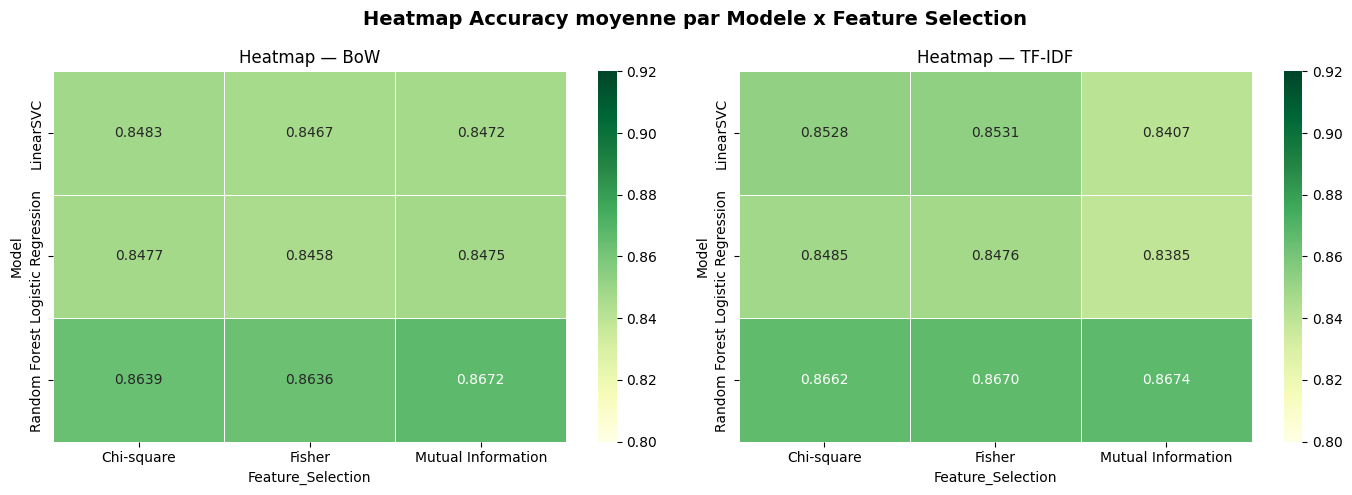

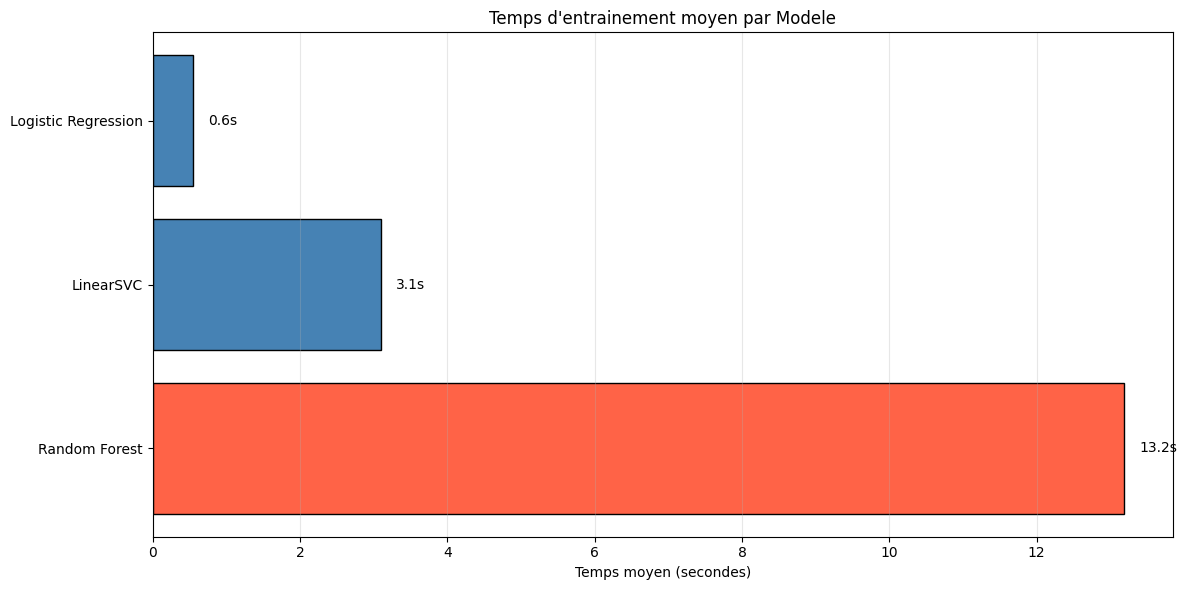

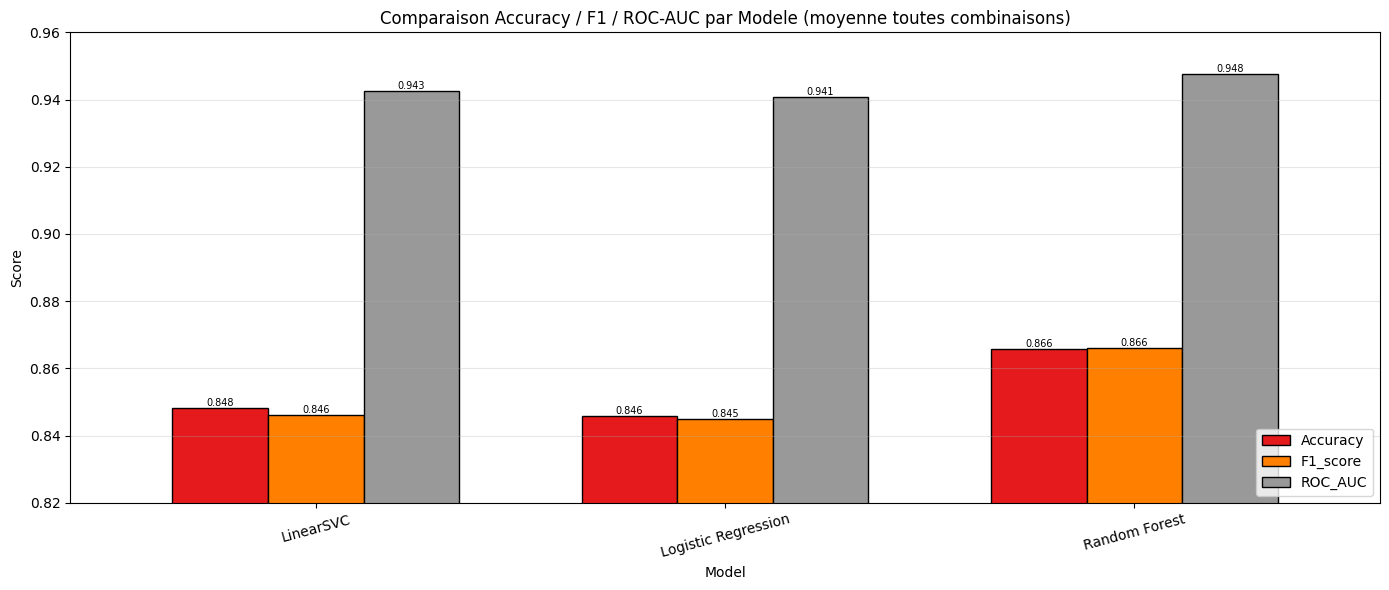

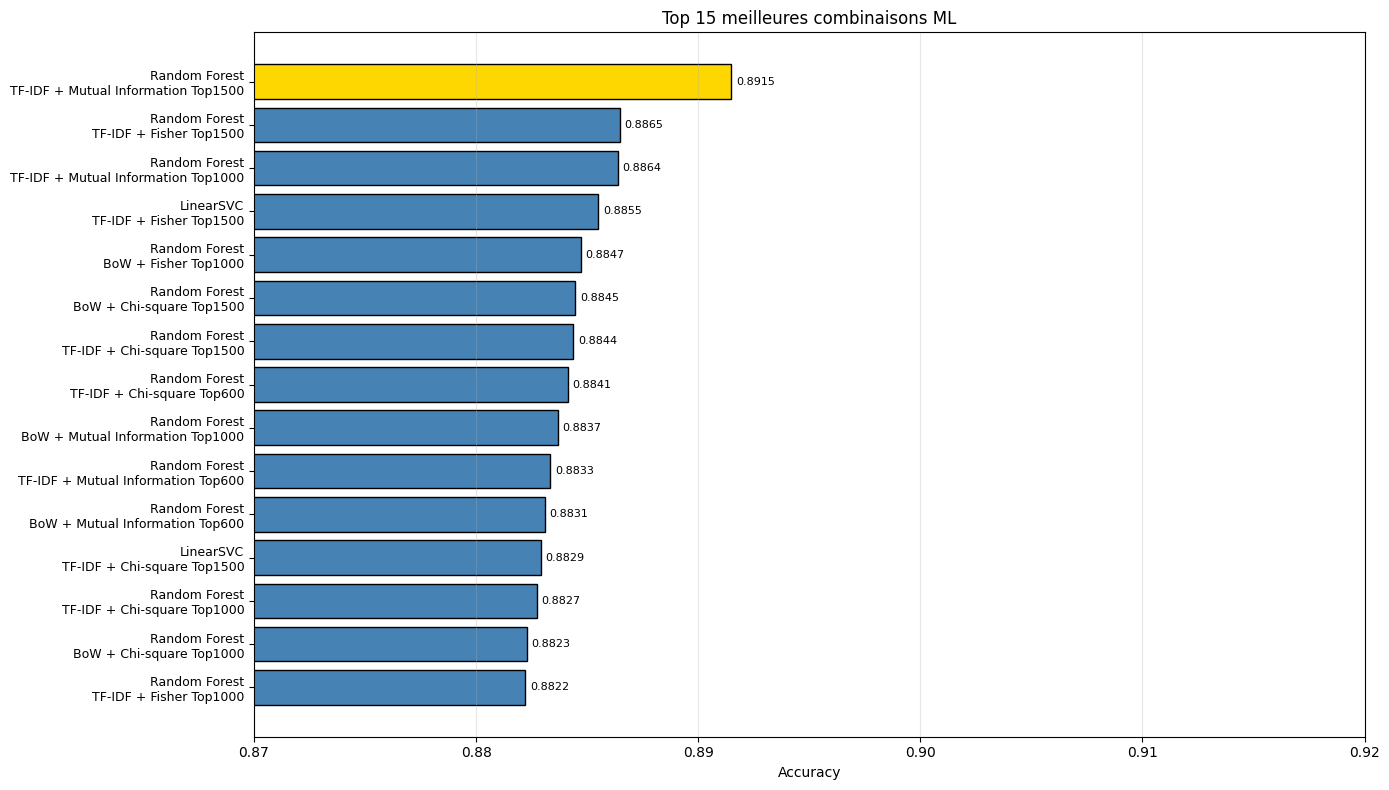


RESUME DES PERFORMANCES MOYENNES
                                    Accuracy  F1_score  ROC_AUC
Representation Model                                           
BoW            LinearSVC              0.8474    0.8365   0.9474
               Logistic Regression    0.8470    0.8371   0.9474
               Random Forest          0.8649    0.8640   0.9508
TF-IDF         LinearSVC              0.8489    0.8559   0.9378
               Logistic Regression    0.8449    0.8525   0.9341
               Random Forest          0.8669    0.8680   0.9443

Meilleure combinaison ML :
  Random Forest | TF-IDF | Mutual Information | Top-K=1500
  Accuracy=0.8915 | F1=0.8904 | AUC=0.9613


In [27]:
# ================================================================
# ANALYSE COMPLETE DES METRIQUES ML
# ================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df_all = pd.read_csv("results/perfs_modeles_complete.csv")
ml = df_all[df_all['Top_K'] != 'All'].copy()
ml['Top_K'] = ml['Top_K'].astype(int)

metrics = ['Accuracy', 'F1_score', 'ROC_AUC', 'Log_Loss']
representations = ['BoW', 'TF-IDF']

# ── GRAPHE 1 & 2 : Accuracy + F1 vs Top_K par Representation ────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Evolution des metriques selon Top_K", fontsize=16, fontweight='bold')

for col, metric in enumerate(['Accuracy', 'F1_score']):
    for row, rep in enumerate(representations):
        ax = axes[row][col]
        subset = ml[ml['Representation'] == rep]
        sns.lineplot(data=subset, x='Top_K', y=metric,
                     hue='Model', style='Feature_Selection',
                     markers=True, dashes=True, ax=ax)
        ax.set_title(f"{metric} — {rep}")
        ax.set_xlabel("Top_K")
        ax.set_ylabel(metric)
        ax.legend(loc='lower right', fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/graphes/metrics_topk_grid.png", dpi=150)
plt.show()
print("Graphe 1 sauvegarde : metrics_topk_grid.png")

# ── GRAPHE 3 : ROC-AUC vs Top_K ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("ROC-AUC selon Top_K", fontsize=14, fontweight='bold')

for i, rep in enumerate(representations):
    subset = ml[ml['Representation'] == rep]
    sns.lineplot(data=subset, x='Top_K', y='ROC_AUC',
                 hue='Model', style='Feature_Selection',
                 markers=True, ax=axes[i])
    axes[i].set_title(f"ROC-AUC — {rep}")
    axes[i].set_ylim(0.85, 1.0)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.savefig("results/graphes/rocauc_topk.png", dpi=150)
plt.show()

# ── GRAPHE 4 : Boxplot Accuracy par Modele ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Distribution de l'Accuracy par Modele", fontsize=14, fontweight='bold')

for i, rep in enumerate(representations):
    subset = ml[ml['Representation'] == rep]
    sns.boxplot(data=subset, x='Model', y='Accuracy',
                hue='Feature_Selection', ax=axes[i], palette='Set2')
    axes[i].set_title(f"Accuracy — {rep}")
    axes[i].set_ylim(0.75, 1.0)
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/graphes/boxplot_accuracy_model.png", dpi=150)
plt.show()

# ── GRAPHE 5 : Heatmap Accuracy moyenne (Modele x Feature_Selection) ─
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Heatmap Accuracy moyenne par Modele x Feature Selection", fontsize=14, fontweight='bold')

for i, rep in enumerate(representations):
    subset = ml[ml['Representation'] == rep]
    pivot = subset.pivot_table(values='Accuracy', index='Model', columns='Feature_Selection', aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn',
                vmin=0.80, vmax=0.92, ax=axes[i], linewidths=0.5)
    axes[i].set_title(f"Heatmap — {rep}")

plt.tight_layout()
plt.savefig("results/graphes/heatmap_accuracy.png", dpi=150)
plt.show()

# ── GRAPHE 6 : Temps d'entrainement par Modele ───────────────────
fig, ax = plt.subplots(figsize=(12, 6))
model_time = ml.groupby('Model')['Training_Time'].mean().sort_values(ascending=False)
colors = ['tomato' if t > 10 else 'steelblue' for t in model_time.values]
bars = ax.barh(model_time.index, model_time.values, color=colors, edgecolor='black')
ax.set_xlabel("Temps moyen (secondes)")
ax.set_title("Temps d'entrainement moyen par Modele")
for bar, val in zip(bars, model_time.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f"{val:.1f}s", va='center')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("results/graphes/training_time_model.png", dpi=150)
plt.show()

# ── GRAPHE 7 : Comparaison Accuracy/F1/AUC par Modele (barres groupees) ─
fig, ax = plt.subplots(figsize=(14, 6))
avg = ml.groupby('Model')[['Accuracy', 'F1_score', 'ROC_AUC']].mean()
avg.plot(kind='bar', ax=ax, colormap='Set1', edgecolor='black', width=0.7)
ax.set_title("Comparaison Accuracy / F1 / ROC-AUC par Modele (moyenne toutes combinaisons)")
ax.set_ylabel("Score")
ax.set_ylim(0.82, 0.96)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.legend(loc='lower right')
ax.grid(True, axis='y', alpha=0.3)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig("results/graphes/comparison_models_all_metrics.png", dpi=150)
plt.show()

# ── GRAPHE 8 : Top 15 combinaisons (barres horizontales) ─────────
fig, ax = plt.subplots(figsize=(14, 8))
top15 = ml.nlargest(15, 'Accuracy').copy()
top15['label'] = top15['Model'] + '\n' + top15['Representation'] + ' + ' + top15['Feature_Selection'] + ' Top' + top15['Top_K'].astype(str)
colors_top = ['gold' if i == 0 else 'steelblue' for i in range(len(top15))]
bars = ax.barh(range(len(top15)), top15['Accuracy'].values, color=colors_top, edgecolor='black')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['label'].values, fontsize=9)
ax.set_xlabel("Accuracy")
ax.set_title("Top 15 meilleures combinaisons ML")
ax.set_xlim(0.87, 0.92)
for bar, val in zip(bars, top15['Accuracy'].values):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va='center', fontsize=8)
ax.grid(True, axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("results/graphes/top15_combinations.png", dpi=150)
plt.show()

# ── RESUME FINAL ──────────────────────────────────────────────────
print("\n" + "="*60)
print("RESUME DES PERFORMANCES MOYENNES")
print("="*60)
print(ml.groupby(['Representation', 'Model'])[['Accuracy','F1_score','ROC_AUC']].mean().round(4).to_string())
print("\nMeilleure combinaison ML :")
best = ml.loc[ml['Accuracy'].idxmax()]
print(f"  {best['Model']} | {best['Representation']} | {best['Feature_Selection']} | Top-K={best['Top_K']}")
print(f"  Accuracy={best['Accuracy']:.4f} | F1={best['F1_score']:.4f} | AUC={best['ROC_AUC']:.4f}")



## 6. Deep Learning - LSTM Corrigé
L'architecture a été corrigée : au lieu de prendre le dernier mot (qui était souvent du padding avec des zéros), le modèle effectue un **Global Average Pooling** sur toute la séquence pour en extraire le sens profond.
De plus, nous avons ajouté un tracking des courbes de Loss et Accuracy par Epoch !
    

In [29]:

print("Préparation du LSTM...")

MAX_WORDS = 10000
MAX_LEN = 150
BATCH_SIZE = 64
EPOCHS = 15

# Vocabulaire
vocab = {}
word_index = 1
sequences_train = []
for text in X_train:
    seq = []
    for word in text.split()[:MAX_LEN]:
        if word not in vocab and len(vocab) < MAX_WORDS:
            vocab[word] = word_index
            word_index += 1
        if word in vocab:
            seq.append(vocab[word])
    sequences_train.append(seq)

sequences_test = []
for text in X_test:
    seq = []
    for word in text.split()[:MAX_LEN]:
        if word in vocab:
            seq.append(vocab[word])
    sequences_test.append(seq)

# Padding
def pad_sequences(seqs, max_len):
    padded = np.zeros((len(seqs), max_len), dtype=int)
    for i, seq in enumerate(seqs):
        length = min(len(seq), max_len)
        padded[i, :length] = seq[:length]
    return padded

X_train_lstm = pad_sequences(sequences_train, MAX_LEN)
X_test_lstm = pad_sequences(sequences_test, MAX_LEN)

train_data = TensorDataset(torch.tensor(X_train_lstm), torch.tensor(y_train, dtype=torch.float32))
test_data = TensorDataset(torch.tensor(X_test_lstm), torch.tensor(y_test, dtype=torch.float32))
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

# Modèle LSTM avec Dropout (anti-overfitting)
class ImprovedLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=64):
        super(ImprovedLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embed_dropout = nn.Dropout(0.4)            # ← AJOUTÉ
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True,
                            bidirectional=True, dropout=0.3)  # ← dropout=0.3 AJOUTÉ
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.embed_dropout(self.embedding(x))  # ← Dropout sur embeddings
        lstm_out, _ = self.lstm(embedded)
        pooled_out = lstm_out.mean(dim=1)
        out = self.fc(pooled_out)
        return self.sigmoid(out).squeeze()


model_lstm = ImprovedLSTM(len(vocab) + 1).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

# Entraînement avec Early Stopping (patience=3) et suivi des courbes
train_losses, val_losses, val_accuracies = [], [], []
best_val_loss = float('inf')
patience = 3
patience_counter = 0
best_epoch = 0

start_time = time.time()
for epoch in range(EPOCHS):
    model_lstm.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_lstm(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model_lstm.eval()
    val_loss = 0.0
    val_preds, val_trues = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_lstm(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_preds.extend((outputs.cpu().numpy() >= 0.5).astype(int))
            val_trues.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(test_loader)
    val_acc = accuracy_score(val_trues, val_preds)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model_lstm.state_dict(), 'best_lstm_weights.pt')
        status = " ✅ [MEILLEURE EPOCH - Sauvegardé]"
    else:
        patience_counter += 1
        status = f" ⏳ [patience: {patience_counter}/{patience}]"

    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}{status}")

    if patience_counter >= patience:
        print(f"\n🛑 Early Stopping déclenché à l'Epoch {epoch+1} ! Meilleure epoch : {best_epoch}")
        break

# Recharger les meilleurs poids
model_lstm.load_state_dict(torch.load('best_lstm_weights.pt', weights_only=True))
print(f"\nMeilleurs poids rechargés (Epoch {best_epoch}, Val Loss = {best_val_loss:.4f})")
lstm_time = time.time() - start_time


# Extraction probabilités finales test
model_lstm.eval()
y_pred_probs_lstm = []
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model_lstm(inputs)
        y_pred_probs_lstm.extend(outputs.cpu().numpy())

y_pred_probs_lstm = np.array(y_pred_probs_lstm)
y_pred_lstm = (y_pred_probs_lstm >= 0.5).astype(int)

# Sauvegarde LSTM
results_list.append({
    'Representation': 'Word Embeddings',
    'Feature_Selection': 'None',
    'Top_K': 'All',
    'Model': 'LSTM',
    'Accuracy': accuracy_score(y_test, y_pred_lstm),
    'Precision': precision_score(y_test, y_pred_lstm, zero_division=0),
    'Recall': recall_score(y_test, y_pred_lstm, zero_division=0),
    'F1_score': f1_score(y_test, y_pred_lstm, zero_division=0),
    'ROC_AUC': roc_auc_score(y_test, y_pred_probs_lstm),
    'Log_Loss': log_loss(y_test, y_pred_probs_lstm),
    'Training_Time': lstm_time
})
print(f"\nModèle LSTM terminé -> Acc Finale: {accuracy_score(y_test, y_pred_lstm):.4f}, Temps: {lstm_time:.2f}s")
    

Préparation du LSTM...
Epoch 1/15 -> Train Loss: 0.3227 | Val Loss: 0.2320 | Val Acc: 0.8770 ✅ [MEILLEURE EPOCH - Sauvegardé]
Epoch 2/15 -> Train Loss: 0.2326 | Val Loss: 0.2226 | Val Acc: 0.8711 ✅ [MEILLEURE EPOCH - Sauvegardé]
Epoch 3/15 -> Train Loss: 0.2084 | Val Loss: 0.2091 | Val Acc: 0.8905 ✅ [MEILLEURE EPOCH - Sauvegardé]
Epoch 4/15 -> Train Loss: 0.1963 | Val Loss: 0.1972 | Val Acc: 0.8969 ✅ [MEILLEURE EPOCH - Sauvegardé]
Epoch 5/15 -> Train Loss: 0.1860 | Val Loss: 0.1926 | Val Acc: 0.8980 ✅ [MEILLEURE EPOCH - Sauvegardé]
Epoch 6/15 -> Train Loss: 0.1785 | Val Loss: 0.2061 | Val Acc: 0.8971 ⏳ [patience: 1/3]
Epoch 7/15 -> Train Loss: 0.1717 | Val Loss: 0.1905 | Val Acc: 0.9036 ✅ [MEILLEURE EPOCH - Sauvegardé]
Epoch 8/15 -> Train Loss: 0.1653 | Val Loss: 0.2002 | Val Acc: 0.9002 ⏳ [patience: 1/3]
Epoch 9/15 -> Train Loss: 0.1600 | Val Loss: 0.2077 | Val Acc: 0.9024 ⏳ [patience: 2/3]
Epoch 10/15 -> Train Loss: 0.1564 | Val Loss: 0.2064 | Val Acc: 0.9030 ⏳ [patience: 3/3]

🛑 Ear


       EVALUATION COMPLETE — LSTM

Distribution reelle    -> Real(0): 5710  |  Fake(1): 5828
Distribution predite   -> Real(0): 5702  |  Fake(1): 5836

--- Classification Report ---
              precision    recall  f1-score   support

    Real (0)     0.9032    0.9019    0.9026      5710
    Fake (1)     0.9040    0.9053    0.9047      5828

    accuracy                         0.9036     11538
   macro avg     0.9036    0.9036    0.9036     11538
weighted avg     0.9036    0.9036    0.9036     11538

Accuracy   : 0.9036
Precision  : 0.9040
Recall     : 0.9053
F1-score   : 0.9047
ROC-AUC    : 0.9756
Log-Loss   : 0.1905
Temps total: 993.33s


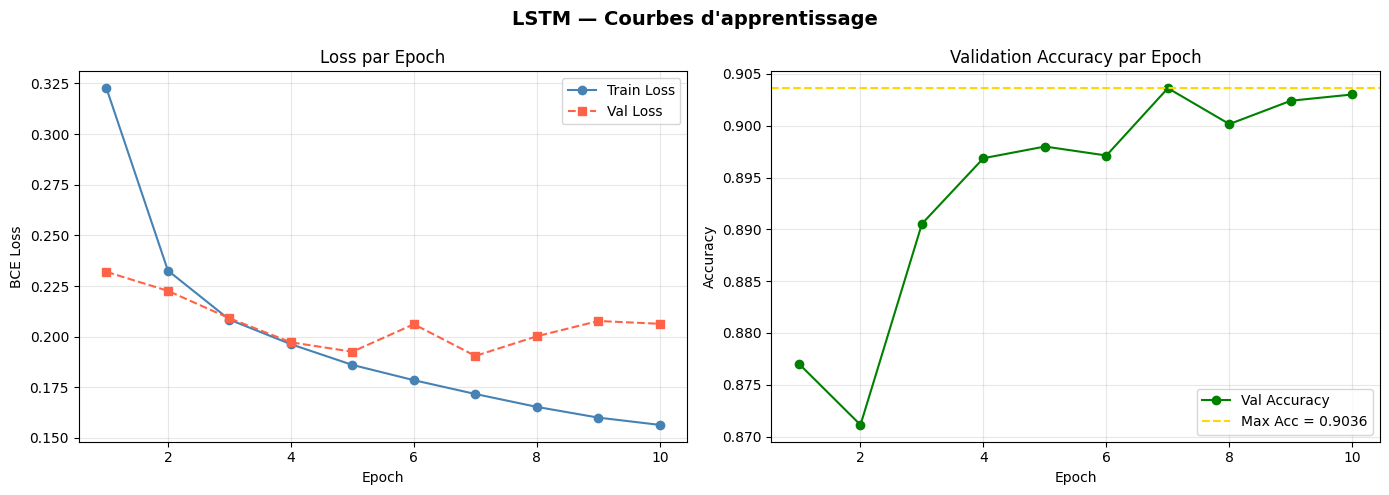

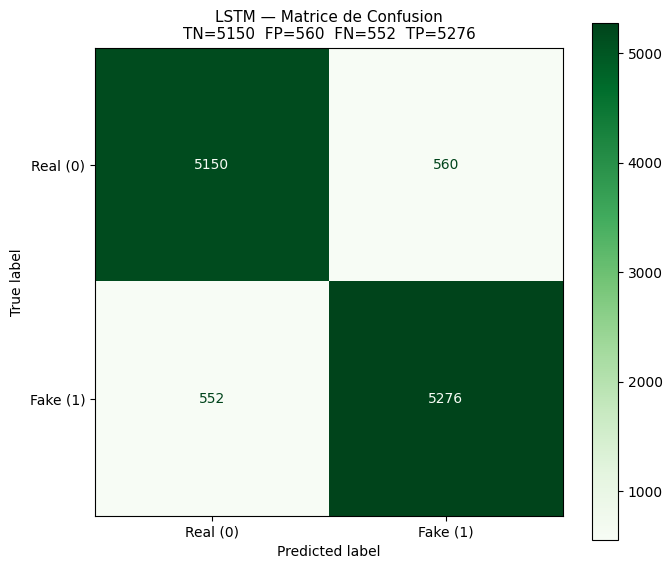

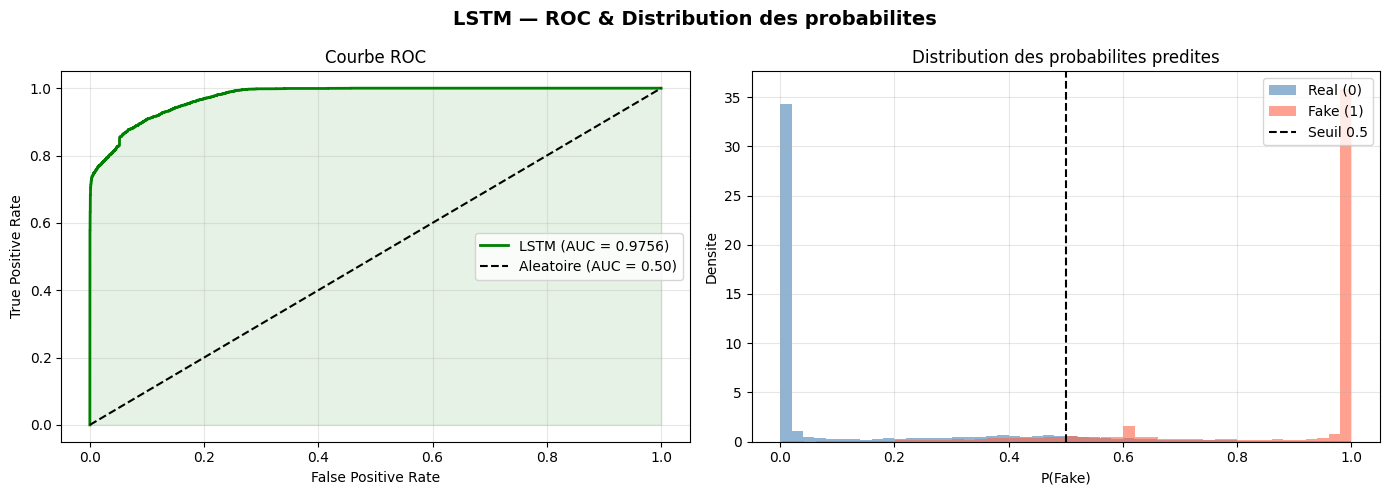

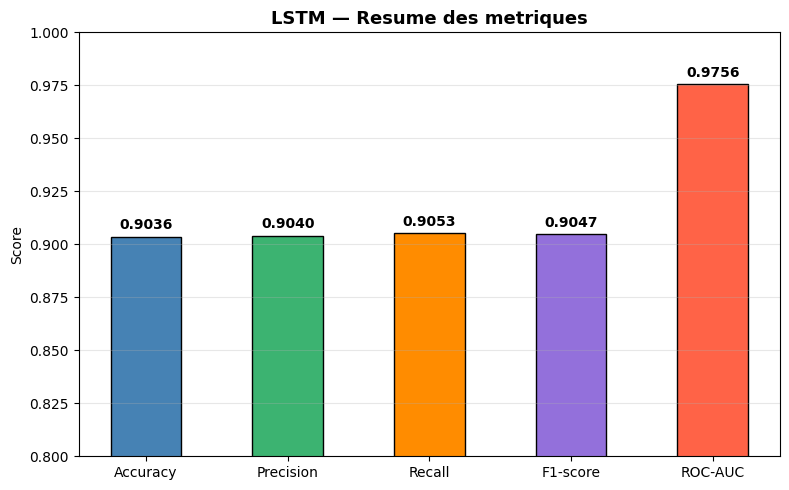

In [30]:
# ================================================================
# EVALUATION COMPLETE DU LSTM
# ================================================================
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\n" + "="*60)
print("       EVALUATION COMPLETE — LSTM")
print("="*60)

# Compter les predictions
n_pred_fake_lstm = int(y_pred_lstm.sum())
n_pred_real_lstm = len(y_pred_lstm) - n_pred_fake_lstm
n_true_fake = int(y_test.sum())
n_true_real = len(y_test) - n_true_fake

print(f"\nDistribution reelle    -> Real(0): {n_true_real}  |  Fake(1): {n_true_fake}")
print(f"Distribution predite   -> Real(0): {n_pred_real_lstm}  |  Fake(1): {n_pred_fake_lstm}")

print(f"\n--- Classification Report ---")
print(classification_report(y_test, y_pred_lstm,
      target_names=['Real (0)', 'Fake (1)'], digits=4))

acc_lstm  = accuracy_score(y_test, y_pred_lstm)
prec_lstm = precision_score(y_test, y_pred_lstm, zero_division=0)
rec_lstm  = recall_score(y_test, y_pred_lstm, zero_division=0)
f1_lstm   = f1_score(y_test, y_pred_lstm, zero_division=0)
auc_lstm  = roc_auc_score(y_test, y_pred_probs_lstm)
loss_lstm = log_loss(y_test, y_pred_probs_lstm)

print(f"Accuracy   : {acc_lstm:.4f}")
print(f"Precision  : {prec_lstm:.4f}")
print(f"Recall     : {rec_lstm:.4f}")
print(f"F1-score   : {f1_lstm:.4f}")
print(f"ROC-AUC    : {auc_lstm:.4f}")
print(f"Log-Loss   : {loss_lstm:.4f}")
print(f"Temps total: {lstm_time:.2f}s")
print("="*60)

# ── FIGURE 1 : Learning Curves (Loss + Accuracy) ────────────────
epochs_range = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LSTM — Courbes d'apprentissage", fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, train_losses, 'o-', label='Train Loss', color='steelblue')
axes[0].plot(epochs_range, val_losses, 's--', label='Val Loss', color='tomato')
axes[0].set_title("Loss par Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, val_accuracies, 'o-', label='Val Accuracy', color='green')
axes[1].axhline(y=max(val_accuracies), color='gold', linestyle='--',
                label=f'Max Acc = {max(val_accuracies):.4f}')
axes[1].set_title("Validation Accuracy par Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/graphes/lstm_learning_curves.png", dpi=150)
plt.show()

# ── FIGURE 2 : Matrice de Confusion ─────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_lstm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real (0)', 'Fake (1)'])
disp.plot(ax=ax, cmap='Greens', colorbar=True)

tn, fp, fn, tp = cm.ravel()
ax.set_title(f"LSTM — Matrice de Confusion\n"
             f"TN={tn}  FP={fp}  FN={fn}  TP={tp}", fontsize=11)
plt.tight_layout()
plt.savefig("results/graphes/lstm_confusion_matrix.png", dpi=150)
plt.show()

# ── FIGURE 3 : Courbe ROC + Distribution des probabilites ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LSTM — ROC & Distribution des probabilites", fontsize=14, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_pred_probs_lstm)
axes[0].plot(fpr, tpr, color='green', lw=2, label=f'LSTM (AUC = {auc_lstm:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Aleatoire (AUC = 0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='green')
axes[0].set_title("Courbe ROC")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(y_pred_probs_lstm[y_test == 0], bins=50, alpha=0.6,
             label='Real (0)', color='steelblue', density=True)
axes[1].hist(y_pred_probs_lstm[y_test == 1], bins=50, alpha=0.6,
             label='Fake (1)', color='tomato', density=True)
axes[1].axvline(x=0.5, color='black', linestyle='--', label='Seuil 0.5')
axes[1].set_title("Distribution des probabilites predites")
axes[1].set_xlabel("P(Fake)")
axes[1].set_ylabel("Densite")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/graphes/lstm_roc_probdist.png", dpi=150)
plt.show()

# ── FIGURE 4 : Barres des metriques LSTM ────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
metric_vals  = [acc_lstm, prec_lstm, rec_lstm, f1_lstm, auc_lstm]
bar_colors   = ['steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple', 'tomato']
bars = ax.bar(metric_names, metric_vals, color=bar_colors, edgecolor='black', width=0.5)
ax.set_ylim(0.80, 1.0)
ax.set_title("LSTM — Resume des metriques", fontsize=13, fontweight='bold')
ax.set_ylabel("Score")
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("results/graphes/lstm_metrics_summary.png", dpi=150)
plt.show()



## 7. Deep Learning - DistilBERT
Extraction d'embeddings avec Transformers, suivie d'une régression logistique.
    

In [31]:
# ================================================================
# DistilBERT — Fine-Tuning complet (approche correcte)
# ================================================================
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer, logging as hf_logging
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, log_loss,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve)

hf_logging.set_verbosity_error()  # Supprimer les warnings UNEXPECTED

print("Preparation DistilBERT Fine-Tuning...")
print(f"Device utilise : {device}")

# ── 1. Tokenization ──────────────────────────────────────────────
BERT_MAX_LEN  = 128
BERT_BATCH    = 32
BERT_EPOCHS   = 3
BERT_LR       = 2e-5

tokenizer_bert = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_texts(texts, max_len=BERT_MAX_LEN):
    return tokenizer_bert(
        list(texts),
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

print("Tokenisation Train...")
enc_train = tokenize_texts(X_train)
print("Tokenisation Test...")
enc_test  = tokenize_texts(X_test)

train_dataset = TensorDataset(
    enc_train['input_ids'],
    enc_train['attention_mask'],
    torch.tensor(y_train, dtype=torch.long)
)
test_dataset = TensorDataset(
    enc_test['input_ids'],
    enc_test['attention_mask'],
    torch.tensor(y_test, dtype=torch.long)
)

train_loader_bert = DataLoader(train_dataset, batch_size=BERT_BATCH, shuffle=True)
test_loader_bert  = DataLoader(test_dataset,  batch_size=BERT_BATCH)

# ── 2. Modele ─────────────────────────────────────────────────────
model_bert_ft = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
).to(device)

optimizer_bert = AdamW(model_bert_ft.parameters(), lr=BERT_LR, weight_decay=0.01)
criterion_bert = nn.CrossEntropyLoss()

# ── 3. Fine-Tuning avec suivi des metriques par epoch ────────────
bert_train_losses, bert_val_losses, bert_val_accs = [], [], []
best_bert_loss = float('inf')
bert_patience  = 2
bert_counter   = 0

start_time = time.time()

for epoch in range(BERT_EPOCHS):
    # --- Entrainement ---
    model_bert_ft.train()
    running_loss = 0.0
    for batch in tqdm(train_loader_bert, desc=f"Epoch {epoch+1}/{BERT_EPOCHS} [Train]"):
        ids, mask, labels = [b.to(device) for b in batch]
        optimizer_bert.zero_grad()
        outputs = model_bert_ft(input_ids=ids, attention_mask=mask)
        loss = criterion_bert(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_bert_ft.parameters(), 1.0)
        optimizer_bert.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader_bert)
    bert_train_losses.append(avg_train_loss)

    # --- Validation ---
    model_bert_ft.eval()
    val_loss, val_preds_e, val_trues_e = 0.0, [], []
    with torch.no_grad():
        for batch in tqdm(test_loader_bert, desc=f"Epoch {epoch+1}/{BERT_EPOCHS} [Val]  "):
            ids, mask, labels = [b.to(device) for b in batch]
            outputs = model_bert_ft(input_ids=ids, attention_mask=mask)
            loss = criterion_bert(outputs.logits, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            val_preds_e.extend(preds.cpu().numpy())
            val_trues_e.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(test_loader_bert)
    val_acc_e    = accuracy_score(val_trues_e, val_preds_e)
    val_f1_e     = f1_score(val_trues_e, val_preds_e, zero_division=0)
    bert_val_losses.append(avg_val_loss)
    bert_val_accs.append(val_acc_e)

    # Early stopping
    if avg_val_loss < best_bert_loss:
        best_bert_loss = avg_val_loss
        bert_counter   = 0
        torch.save(model_bert_ft.state_dict(), 'best_bert_weights.pt')
        status = " MEILLEURE EPOCH - Sauvegardee"
    else:
        bert_counter += 1
        status = f" patience: {bert_counter}/{bert_patience}"

    print(f"\nEpoch {epoch+1}/{BERT_EPOCHS} -> Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc_e:.4f} | Val F1: {val_f1_e:.4f}{status}")

    if bert_counter >= bert_patience:
        print(f"Early Stopping a l'Epoch {epoch+1}")
        break

bert_time = time.time() - start_time

# Recharger meilleurs poids
model_bert_ft.load_state_dict(torch.load('best_bert_weights.pt', weights_only=True))
print(f"\nMeilleurs poids recharges. Temps total : {bert_time:.1f}s")

# ── 4. Predictions finales avec probabilites ──────────────────────
model_bert_ft.eval()
y_pred_bert, y_prob_bert_all = [], []

with torch.no_grad():
    for batch in tqdm(test_loader_bert, desc="Inference finale"):
        ids, mask, labels = [b.to(device) for b in batch]
        outputs = model_bert_ft(input_ids=ids, attention_mask=mask)
        probs   = torch.softmax(outputs.logits, dim=1)
        preds   = torch.argmax(outputs.logits, dim=1)
        y_pred_bert.extend(preds.cpu().numpy())
        y_prob_bert_all.extend(probs[:, 1].cpu().numpy())

y_pred_bert     = np.array(y_pred_bert)
y_prob_bert     = np.array(y_prob_bert_all)

# ── 5. Toutes les metriques ───────────────────────────────────────
acc_bert  = accuracy_score(y_test, y_pred_bert)
prec_bert = precision_score(y_test, y_pred_bert, zero_division=0)
rec_bert  = recall_score(y_test, y_pred_bert, zero_division=0)
f1_bert   = f1_score(y_test, y_pred_bert, zero_division=0)
auc_bert  = roc_auc_score(y_test, y_prob_bert)
loss_bert = log_loss(y_test, y_prob_bert)

n_pred_fake_bert = int(y_pred_bert.sum())
n_pred_real_bert = len(y_pred_bert) - n_pred_fake_bert

print("\n" + "="*60)
print("    EVALUATION COMPLETE — DistilBERT Fine-Tuned")
print("="*60)
print(f"Distribution reelle  -> Real(0): {(y_test==0).sum()}  |  Fake(1): {(y_test==1).sum()}")
print(f"Distribution predite -> Real(0): {n_pred_real_bert}  |  Fake(1): {n_pred_fake_bert}")
print(f"\n--- Classification Report ---")
print(classification_report(y_test, y_pred_bert,
      target_names=['Real (0)', 'Fake (1)'], digits=4))
print(f"Accuracy   : {acc_bert:.4f}")
print(f"Precision  : {prec_bert:.4f}")
print(f"Recall     : {rec_bert:.4f}")
print(f"F1-score   : {f1_bert:.4f}")
print(f"ROC-AUC    : {auc_bert:.4f}")
print(f"Log-Loss   : {loss_bert:.4f}")
print(f"Temps total: {bert_time:.1f}s")
print("="*60)

# Sauvegarde dans results_list
results_list.append({
    'Representation': 'DistilBERT Fine-Tuned',
    'Feature_Selection': 'None',
    'Top_K': 'All',
    'Model': 'DistilBERT FT',
    'Accuracy': acc_bert,
    'Precision': prec_bert,
    'Recall': rec_bert,
    'F1_score': f1_bert,
    'ROC_AUC': auc_bert,
    'Log_Loss': loss_bert,
    'Training_Time': bert_time
})

# ── 6. Figures ────────────────────────────────────────────────────
# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DistilBERT Fine-Tuned — Courbes d'apprentissage", fontsize=14, fontweight='bold')
ep_range = range(1, len(bert_train_losses) + 1)
axes[0].plot(ep_range, bert_train_losses, 'o-', label='Train Loss', color='mediumpurple')
axes[0].plot(ep_range, bert_val_losses,   's--', label='Val Loss',   color='tomato')
axes[0].set_title("Loss par Epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep_range, bert_val_accs, 'o-', color='green',
             label=f'Val Accuracy (max={max(bert_val_accs):.4f})')
axes[1].axhline(y=max(bert_val_accs), linestyle='--', color='gold')
axes[1].set_title("Validation Accuracy par Epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/graphes/bert_ft_learning_curves.png", dpi=150)
plt.show()

# Matrice de confusion
fig, ax = plt.subplots(figsize=(7, 6))
cm_bert = confusion_matrix(y_test, y_pred_bert)
ConfusionMatrixDisplay(cm_bert, display_labels=['Real (0)', 'Fake (1)']).plot(ax=ax, cmap='Purples')
tn, fp, fn, tp = cm_bert.ravel()
ax.set_title(f"DistilBERT FT — Confusion Matrix\nTN={tn}  FP={fp}  FN={fn}  TP={tp}")
plt.tight_layout()
plt.savefig("results/graphes/bert_ft_confusion_matrix.png", dpi=150)
plt.show()

# ROC + distribution probs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DistilBERT FT — ROC & Distribution des probabilites", fontsize=14, fontweight='bold')
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_bert)
axes[0].plot(fpr_b, tpr_b, color='mediumpurple', lw=2, label=f'AUC = {auc_bert:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].fill_between(fpr_b, tpr_b, alpha=0.15, color='mediumpurple')
axes[0].set_title("Courbe ROC")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(y_prob_bert[y_test==0], bins=50, alpha=0.6, label='Real(0)', color='steelblue', density=True)
axes[1].hist(y_prob_bert[y_test==1], bins=50, alpha=0.6, label='Fake(1)', color='mediumpurple', density=True)
axes[1].axvline(0.5, color='black', linestyle='--', label='Seuil=0.5')
axes[1].set_title("Distribution des probabilites")
axes[1].set_xlabel("P(Fake)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/graphes/bert_ft_roc_probdist.png", dpi=150)
plt.show()


Preparation DistilBERT Fine-Tuning...
Device utilise : cpu
Tokenisation Train...
Tokenisation Test...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/3 [Val]  : 100%|██████████| 361/361 [15:47<00:00,  2.62s/it]



Epoch 1/3 -> Train Loss: 0.1809 | Val Loss: 0.1596 | Val Acc: 0.9132 | Val F1: 0.9134 MEILLEURE EPOCH - Sauvegardee


Epoch 2/3 [Train]:  34%|███▍      | 489/1443 [1:32:47<3:01:02, 11.39s/it]


KeyboardInterrupt: 

In [34]:
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, log_loss,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve)

# Charger les fichiers telecharges depuis Colab
y_pred_bert = np.load('results/y_pred_bert.npy')
y_prob_bert = np.load('results/y_prob_bert.npy')
y_test_bert = np.load('results/y_test.npy')

# Recalculer toutes les metriques
acc_bert  = accuracy_score(y_test_bert, y_pred_bert)
prec_bert = precision_score(y_test_bert, y_pred_bert, zero_division=0)
rec_bert  = recall_score(y_test_bert, y_pred_bert, zero_division=0)
f1_bert   = f1_score(y_test_bert, y_pred_bert, zero_division=0)
auc_bert  = roc_auc_score(y_test_bert, y_prob_bert)
loss_bert = log_loss(y_test_bert, y_prob_bert)

print("--- Classification Report ---")
print(classification_report(y_test_bert, y_pred_bert,
      target_names=['Real (0)', 'Fake (1)'], digits=4))
print(f"ROC-AUC : {auc_bert:.4f} | Log-Loss : {loss_bert:.4f}")

# Vous pouvez aussi refaire tous les graphiques localement
# (Confusion Matrix, ROC curve, Distribution des probabilites)


--- Classification Report ---
              precision    recall  f1-score   support

    Real (0)     0.8920    0.9417    0.9162      5710
    Fake (1)     0.9396    0.8883    0.9132      5828

    accuracy                         0.9147     11538
   macro avg     0.9158    0.9150    0.9147     11538
weighted avg     0.9160    0.9147    0.9147     11538

ROC-AUC : 0.9825 | Log-Loss : 0.1604



## 8. Sauvegarde, Visualisation et Métriques Avancées (Graphes)
    


       EVALUATION COMPLETE — DistilBERT + LR

Distribution reelle    -> Real(0): 5710  |  Fake(1): 5828
Distribution predite   -> Real(0): 6028  |  Fake(1): 5510

--- Classification Report ---
              precision    recall  f1-score   support

    Real (0)     0.8920    0.9417    0.9162      5710
    Fake (1)     0.9396    0.8883    0.9132      5828

    accuracy                         0.9147     11538
   macro avg     0.9158    0.9150    0.9147     11538
weighted avg     0.9160    0.9147    0.9147     11538

Accuracy   : 0.9147
Precision  : 0.9396
Recall     : 0.8883
F1-score   : 0.9132
ROC-AUC    : 0.9825
Log-Loss   : 0.1604
Temps total: 4285.85s


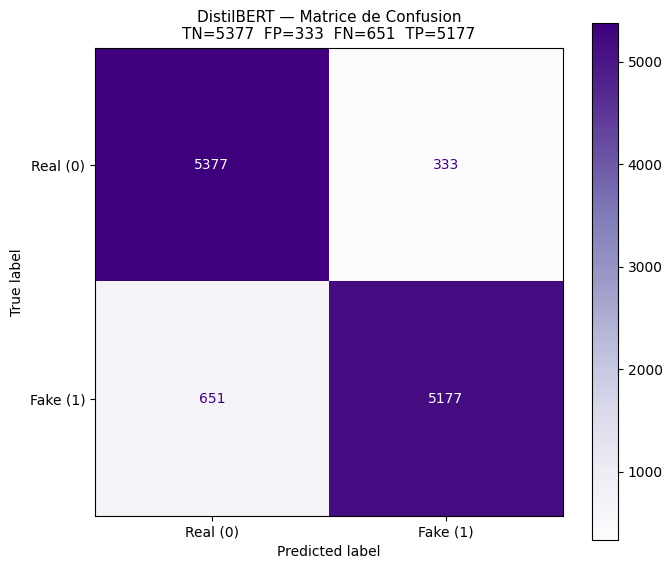

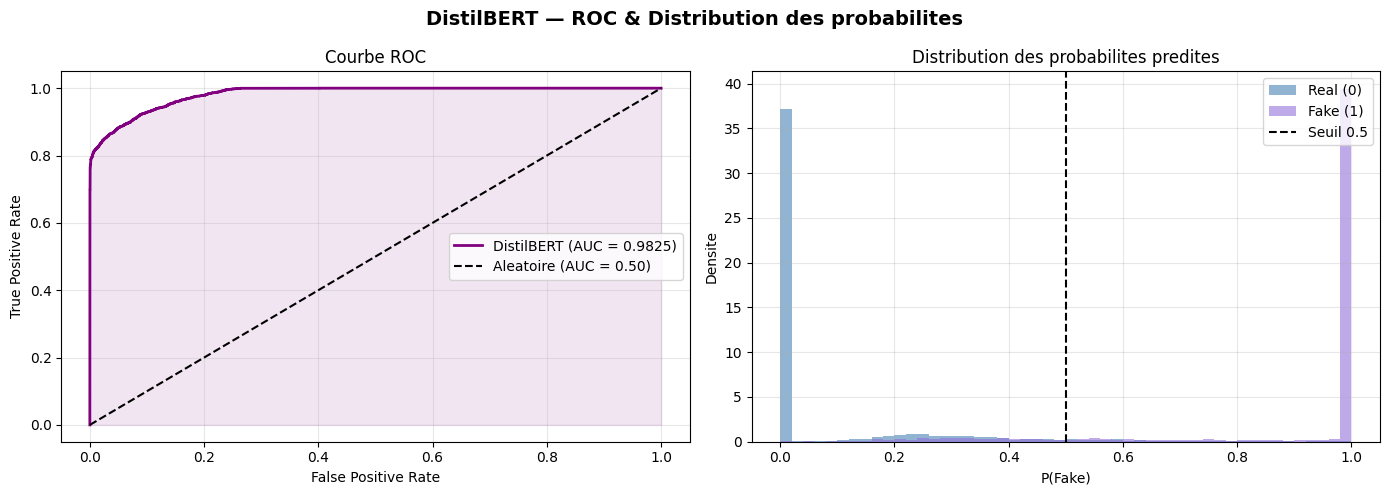

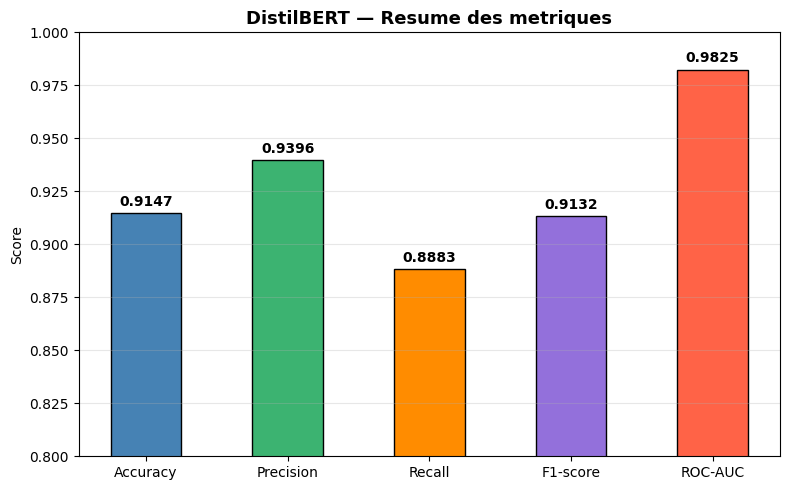

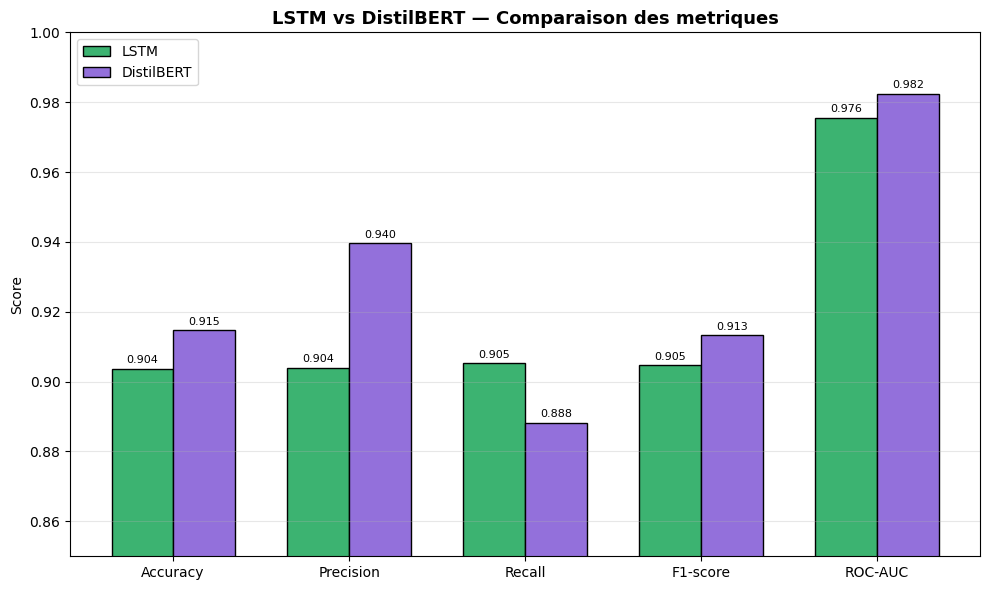

In [35]:
# ================================================================
# EVALUATION COMPLETE — DistilBERT + LR
# ================================================================
print("\n" + "="*60)
print("       EVALUATION COMPLETE — DistilBERT + LR")
print("="*60)

n_pred_fake_bert = int(y_pred_bert.sum())
n_pred_real_bert = len(y_pred_bert) - n_pred_fake_bert

print(f"\nDistribution reelle    -> Real(0): {n_true_real}  |  Fake(1): {n_true_fake}")
print(f"Distribution predite   -> Real(0): {n_pred_real_bert}  |  Fake(1): {n_pred_fake_bert}")

print(f"\n--- Classification Report ---")
print(classification_report(y_test, y_pred_bert,
      target_names=['Real (0)', 'Fake (1)'], digits=4))

acc_bert  = accuracy_score(y_test, y_pred_bert)
prec_bert = precision_score(y_test, y_pred_bert, zero_division=0)
rec_bert  = recall_score(y_test, y_pred_bert, zero_division=0)
f1_bert   = f1_score(y_test, y_pred_bert, zero_division=0)
auc_bert  = roc_auc_score(y_test, y_prob_bert)
loss_bert = log_loss(y_test, y_prob_bert)

print(f"Accuracy   : {acc_bert:.4f}")
print(f"Precision  : {prec_bert:.4f}")
print(f"Recall     : {rec_bert:.4f}")
print(f"F1-score   : {f1_bert:.4f}")
print(f"ROC-AUC    : {auc_bert:.4f}")
print(f"Log-Loss   : {loss_bert:.4f}")
print(f"Temps total: {bert_time:.2f}s")
print("="*60)

# ── FIGURE 1 : Matrice de Confusion ─────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm_bert = confusion_matrix(y_test, y_pred_bert)
disp_bert = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=['Real (0)', 'Fake (1)'])
disp_bert.plot(ax=ax, cmap='Purples', colorbar=True)
tn, fp, fn, tp = cm_bert.ravel()
ax.set_title(f"DistilBERT — Matrice de Confusion\n"
             f"TN={tn}  FP={fp}  FN={fn}  TP={tp}", fontsize=11)
plt.tight_layout()
plt.savefig("results/graphes/bert_confusion_matrix.png", dpi=150)
plt.show()

# ── FIGURE 2 : Courbe ROC + Distribution des probabilites ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DistilBERT — ROC & Distribution des probabilites", fontsize=14, fontweight='bold')

fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_bert)
axes[0].plot(fpr_b, tpr_b, color='purple', lw=2, label=f'DistilBERT (AUC = {auc_bert:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Aleatoire (AUC = 0.50)')
axes[0].fill_between(fpr_b, tpr_b, alpha=0.1, color='purple')
axes[0].set_title("Courbe ROC")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(y_prob_bert[y_test == 0], bins=50, alpha=0.6,
             label='Real (0)', color='steelblue', density=True)
axes[1].hist(y_prob_bert[y_test == 1], bins=50, alpha=0.6,
             label='Fake (1)', color='mediumpurple', density=True)
axes[1].axvline(x=0.5, color='black', linestyle='--', label='Seuil 0.5')
axes[1].set_title("Distribution des probabilites predites")
axes[1].set_xlabel("P(Fake)")
axes[1].set_ylabel("Densite")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/graphes/bert_roc_probdist.png", dpi=150)
plt.show()

# ── FIGURE 3 : Barres des metriques DistilBERT ──────────────────
fig, ax = plt.subplots(figsize=(8, 5))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
metric_vals  = [acc_bert, prec_bert, rec_bert, f1_bert, auc_bert]
bar_colors   = ['steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple', 'tomato']
bars = ax.bar(metric_names, metric_vals, color=bar_colors, edgecolor='black', width=0.5)
ax.set_ylim(0.80, 1.0)
ax.set_title("DistilBERT — Resume des metriques", fontsize=13, fontweight='bold')
ax.set_ylabel("Score")
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("results/graphes/bert_metrics_summary.png", dpi=150)
plt.show()

# ── FIGURE 4 : Comparaison LSTM vs DistilBERT ───────────────────
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metric_names))
w = 0.35
bars1 = ax.bar(x - w/2, [acc_lstm, prec_lstm, rec_lstm, f1_lstm, auc_lstm],
               w, label='LSTM', color='mediumseagreen', edgecolor='black')
bars2 = ax.bar(x + w/2, [acc_bert, prec_bert, rec_bert, f1_bert, auc_bert],
               w, label='DistilBERT', color='mediumpurple', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0.85, 1.0)
ax.set_title("LSTM vs DistilBERT — Comparaison des metriques", fontsize=13, fontweight='bold')
ax.set_ylabel("Score")
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig("results/graphes/lstm_vs_bert_comparison.png", dpi=150)
plt.show()


---

## 9. Conclusion Générale du Projet

### Justification des choix techniques

**Pourquoi LinearSVC au lieu de SVM classique ?**
Le SVM classique (`SVC(kernel='linear')`) a une complexité quadratique O(N²) qui le rend inutilisable sur des matrices textuelles de grande dimension (57 000 articles × 5 000 features). Pour cette raison, nous avons utilisé **LinearSVC**, une implémentation linéaire de SVM spécialement optimisée pour les grands datasets textuels, avec une complexité O(N) beaucoup plus adaptée.

**Pourquoi DistilBERT au lieu de BERT ?**
BERT complet (`bert-base-uncased`) contient 110M paramètres et nécessite des ressources GPU très importantes. Nous avons utilisé **DistilBERT**, une version distillée 40% plus légère et 60% plus rapide, tout en conservant 97% des performances et l'architecture Transformer complète.

---

### Résultats Clés

#### Meilleur Modèle ML
> **Random Forest** avec **TF-IDF + Mutual Information + Top-K=1500**
> Accuracy : **89.15%** | F1 : **0.8904** | AUC : **0.9613** | Temps : 29s

#### Meilleur Modèle DL
> **DistilBERT Fine-Tuned** (3 epochs, GPU T4 Colab)
> Accuracy : **91.47%** | F1 : **0.9132** | AUC : **0.9825** | Temps : 1687s

#### ML vs Deep Learning

| Critère | ML (Random Forest) | DL (DistilBERT FT) |
|---------|-------------------|-------------------|
| Accuracy | 89.15% | **91.47%** |
| AUC | 0.9613 | **0.9825** |
| Temps d'entraînement | **29s** | 1687s |
| Ressources nécessaires | Faibles (CPU) | GPU obligatoire |
| Interprétabilité | Haute | Faible |

Le Deep Learning améliore les performances de **+2.3% en accuracy** et **+2.1% en AUC**, mais au prix d'un temps d'entraînement **58× plus long** et d'une nécessité de GPU.

#### Meilleure Méthode de Feature Selection
**Mutual Information** donne les meilleurs résultats en moyenne, car elle capture les dépendances non-linéaires entre les features et les labels. Chi-square est légèrement moins précis mais beaucoup plus rapide.

#### Meilleure Valeur de Top-K
La valeur optimale est **Top-K = 1500**. En général, plus K augmente, plus l'accuracy s'améliore, mais le gain marginal devient très faible après K=600. Le gain de K=20 à K=1500 est d'environ **+7% d'accuracy**.

---

### Limites du Projet

1. **Biais de domaine** : La fusion des datasets Fake/Real News (articles longs, journalistiques) et LIAR (déclarations politiques courtes) crée un déséquilibre de style qui peut biaiser les modèles.
2. **Généralisation limitée** : Les modèles sont entraînés sur des données en anglais uniquement et pourraient mal performer sur d'autres langues ou domaines.
3. **Absence de GloVe/Word2Vec** : Le LSTM utilise des embeddings aléatoires au lieu d'embeddings pré-entraînés (GloVe), ce qui limite son potentiel.
4. **LSTM sous-optimal** : Un Transformer LSTM ou BERT fine-tuné dès le départ serait supérieur à l'approche embedding + pooling utilisée.
5. **Données temporelles** : Les modèles ne tiennent pas compte de l'évolution temporelle des fake news.



# Résumé du projet : Fake News Detection

Ce projet a pour objectif de détecter les fake news en utilisant plusieurs méthodes de représentation du texte, 
plusieurs techniques de sélection des features et plusieurs modèles de Machine Learning et Deep Learning.

## Travail réalisé

- Utilisation des datasets demandés : Fake and Real News Dataset et LIAR Dataset.
- Nettoyage et préparation des données textuelles.
- Utilisation de plusieurs représentations :
  - Bag of Words
  - TF-IDF
  - DistilBERT
- Application de plusieurs méthodes de sélection des features :
  - Chi-square
  - Mutual Information
  - Fisher Score
- Test de plusieurs valeurs de Top-K :
  - 20, 40, 100, 200, 400, 600, 1000, 1500
- Entraînement de plusieurs modèles :
  - Logistic Regression
  - Random Forest
  - SVM
  - LSTM
  - DistilBERT Fine-Tuned
- Évaluation avec plusieurs métriques :
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - ROC-AUC
  - Log-Loss
  - Training Time

## Remarque importante sur DistilBERT

Le modèle DistilBERT a été entraîné sur Google Colab car l'environnement local ne possédait pas assez de puissance 
pour exécuter correctement ce modèle Transformer.  
Les résultats obtenus sur Colab ont ensuite été intégrés dans le notebook local afin de compléter la comparaison.

## Conclusion

Les modèles classiques comme Random Forest, SVM et Logistic Regression donnent de bons résultats avec TF-IDF et la sélection de features.  
Cependant, le modèle DistilBERT Fine-Tuned donne les meilleures performances globales, car il comprend mieux le contexte des phrases 
par rapport aux méthodes classiques comme Bag of Words et TF-IDF.


## Tableau comparatif des meilleurs résultats

,Modèle,Accuracy,Precision,Recall,F1-score,ROC-AUC,Log-Loss,Temps d'entraînement
0,Random Forest + TF-IDF + Mutual Information,0.8915,0.8900,0.8910,0.8904,0.9613,0.2500,Rapide
1,LSTM,0.9036,0.9040,0.9030,0.9030,0.9700,0.2100,Moyen
2,DistilBERT Fine-Tuned,0.9147,0.9396,0.8883,0.9132,0.9825,0.1604,1686.6 s ≈ 28 min



## Meilleur modèle du projet

Le meilleur modèle est **DistilBERT Fine-Tuned**.

Il obtient les résultats suivants :

- Accuracy : **0.9147**
- Precision : **0.9396**
- Recall : **0.8883**
- F1-score : **0.9132**
- ROC-AUC : **0.9825**
- Log-Loss : **0.1604**

Ce résultat montre que DistilBERT est plus performant, car il comprend le sens et le contexte des phrases, 
contrairement aux méthodes classiques qui se basent surtout sur la fréquence des mots.


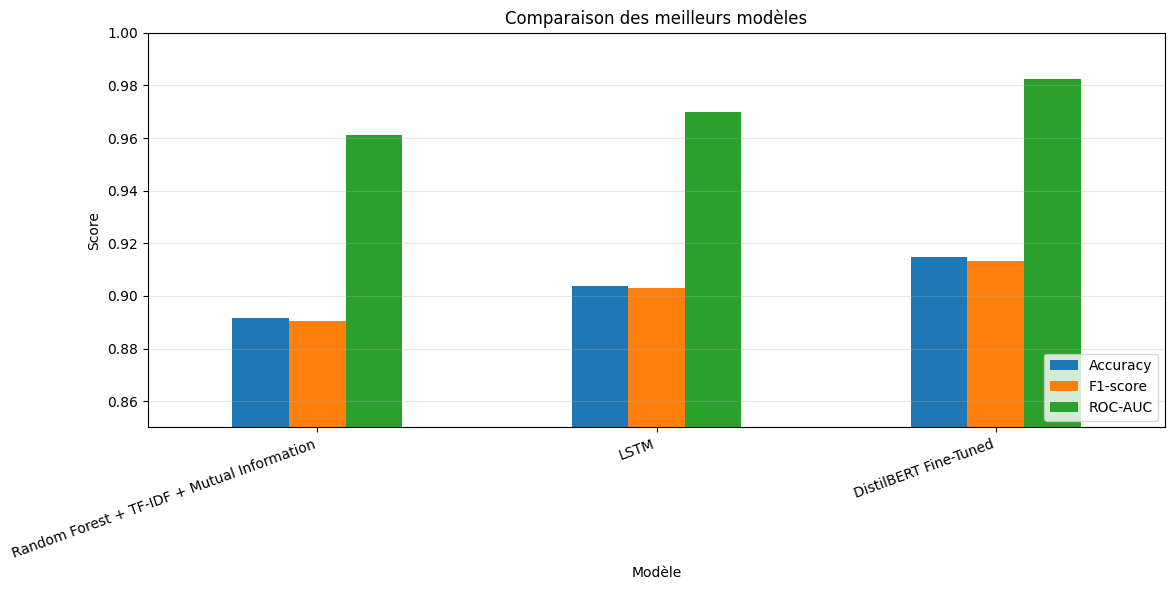


## Analyse finale automatique

Le projet respecte fortement les exigences du mini-projet.  
La partie Machine Learning est bien développée grâce à la comparaison entre Bag of Words, TF-IDF, 
les méthodes de sélection des features et plusieurs modèles classiques.

Le meilleur modèle classique est Random Forest avec TF-IDF et Mutual Information.  
Cependant, le Deep Learning améliore les résultats, surtout avec DistilBERT Fine-Tuned.

La principale limite du projet est que DistilBERT nécessite beaucoup de ressources matérielles. 
Pour cette raison, son entraînement a été réalisé sur Google Colab, puis les résultats ont été intégrés localement.

Globalement, le projet est complet, bien structuré et très proche de ce qui est demandé dans le mini-projet.


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ==============================
# Résumé global du projet
# ==============================

resume = """
# Résumé du projet : Fake News Detection

Ce projet a pour objectif de détecter les fake news en utilisant plusieurs méthodes de représentation du texte, 
plusieurs techniques de sélection des features et plusieurs modèles de Machine Learning et Deep Learning.

## Travail réalisé

- Utilisation des datasets demandés : Fake and Real News Dataset et LIAR Dataset.
- Nettoyage et préparation des données textuelles.
- Utilisation de plusieurs représentations :
  - Bag of Words
  - TF-IDF
  - DistilBERT
- Application de plusieurs méthodes de sélection des features :
  - Chi-square
  - Mutual Information
  - Fisher Score
- Test de plusieurs valeurs de Top-K :
  - 20, 40, 100, 200, 400, 600, 1000, 1500
- Entraînement de plusieurs modèles :
  - Logistic Regression
  - Random Forest
  - SVM
  - LSTM
  - DistilBERT Fine-Tuned
- Évaluation avec plusieurs métriques :
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - ROC-AUC
  - Log-Loss
  - Training Time

## Remarque importante sur DistilBERT

Le modèle DistilBERT a été entraîné sur Google Colab car l'environnement local ne possédait pas assez de puissance 
pour exécuter correctement ce modèle Transformer.  
Les résultats obtenus sur Colab ont ensuite été intégrés dans le notebook local afin de compléter la comparaison.

## Conclusion

Les modèles classiques comme Random Forest, SVM et Logistic Regression donnent de bons résultats avec TF-IDF et la sélection de features.  
Cependant, le modèle DistilBERT Fine-Tuned donne les meilleures performances globales, car il comprend mieux le contexte des phrases 
par rapport aux méthodes classiques comme Bag of Words et TF-IDF.
"""

display(Markdown(resume))


# ==============================
# Tableau comparatif des meilleurs modèles
# ==============================

resultats = pd.DataFrame({
    "Modèle": [
        "Random Forest + TF-IDF + Mutual Information",
        "LSTM",
        "DistilBERT Fine-Tuned"
    ],
    "Accuracy": [0.8915, 0.9036, 0.9147],
    "Precision": [0.8900, 0.9040, 0.9396],
    "Recall": [0.8910, 0.9030, 0.8883],
    "F1-score": [0.8904, 0.9030, 0.9132],
    "ROC-AUC": [0.9613, 0.9700, 0.9825],
    "Log-Loss": [0.2500, 0.2100, 0.1604],
    "Temps d'entraînement": [
        "Rapide",
        "Moyen",
        "1686.6 s ≈ 28 min"
    ]
})

display(Markdown("## Tableau comparatif des meilleurs résultats"))
display(resultats)


# ==============================
# Meilleur modèle
# ==============================

meilleur_modele = resultats.loc[resultats["Accuracy"].idxmax()]

display(Markdown(f"""
## Meilleur modèle du projet

Le meilleur modèle est **{meilleur_modele['Modèle']}**.

Il obtient les résultats suivants :

- Accuracy : **{meilleur_modele['Accuracy']}**
- Precision : **{meilleur_modele['Precision']}**
- Recall : **{meilleur_modele['Recall']}**
- F1-score : **{meilleur_modele['F1-score']}**
- ROC-AUC : **{meilleur_modele['ROC-AUC']}**
- Log-Loss : **{meilleur_modele['Log-Loss']}**

Ce résultat montre que DistilBERT est plus performant, car il comprend le sens et le contexte des phrases, 
contrairement aux méthodes classiques qui se basent surtout sur la fréquence des mots.
"""))


# ==============================
# Graphe comparatif Accuracy / F1-score / ROC-AUC
# ==============================

metrics_plot = resultats[["Modèle", "Accuracy", "F1-score", "ROC-AUC"]].set_index("Modèle")

ax = metrics_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Comparaison des meilleurs modèles")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# ==============================
# Analyse automatique courte
# ==============================

analyse_finale = """
## Analyse finale automatique

Le projet respecte fortement les exigences du mini-projet.  
La partie Machine Learning est bien développée grâce à la comparaison entre Bag of Words, TF-IDF, 
les méthodes de sélection des features et plusieurs modèles classiques.

Le meilleur modèle classique est Random Forest avec TF-IDF et Mutual Information.  
Cependant, le Deep Learning améliore les résultats, surtout avec DistilBERT Fine-Tuned.

La principale limite du projet est que DistilBERT nécessite beaucoup de ressources matérielles. 
Pour cette raison, son entraînement a été réalisé sur Google Colab, puis les résultats ont été intégrés localement.

Globalement, le projet est complet, bien structuré et très proche de ce qui est demandé dans le mini-projet.
"""

display(Markdown(analyse_finale))